In [202]:
# Import for OpenCV
import cv2

import numpy as np
import matplotlib.pyplot as plt 

In [203]:
# Load the image and get it as greyscale
image = cv2.imread("./images/shapes.jpg")

# Check if the image is loaded
if image is None:
    print(" Error: Can't load the image")
else:
    print("Image Loaded Successfully.")

# Conver the image to grey
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


Image Loaded Successfully.


In [204]:
#  Method (1) to use Canny for masking 
#  -------------------------------------------
#  Create a binary mask to detect shape edges
#  Canny expects grey image
img_grey = cv2.Canny(img_grey, 80, 150)
# plt.imshow(img_grey, cmap='grey')

In [205]:
# Pass the grey image to contour detection, take two inputs
# Mode: determines Hirarchical relathionship between contours
# Method: define the way on how the contours points are stored
contours, hierarchy = cv2.findContours(img_grey, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# Create a new contour image copy
contour_image = image.copy()

# Draw contours (Edge detections) -> drawContours(image, , index, color_select, 5)
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 5 )

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

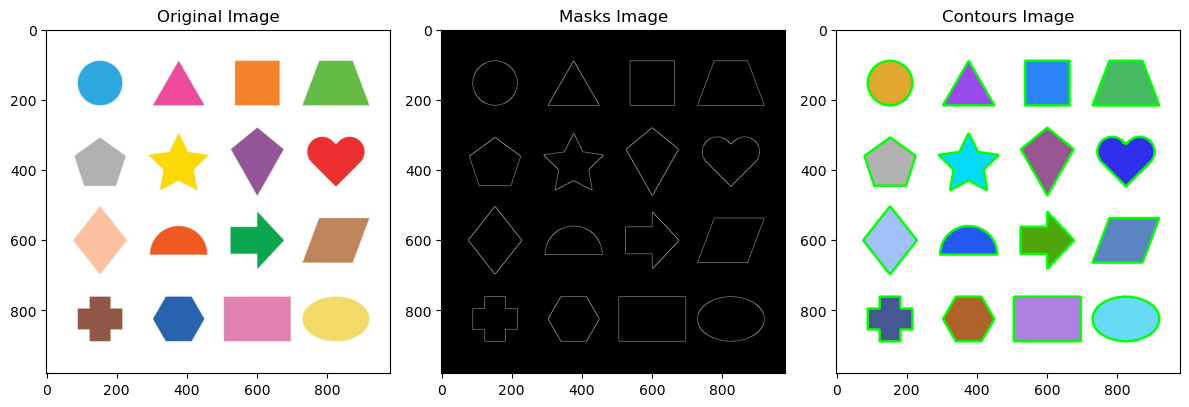

In [206]:
# Plots
# Show all resized images with each algorithm
plt.figure(figsize=(12,9))

# Show the original Image
plt.subplot(1,3,1)
plt.imshow(img_rgb, cmap='grey')
plt.title("Original Image")

# Show the masks image
plt.subplot(1,3,2)
plt.imshow(img_grey, cmap='grey')
plt.title("Masks Image")

# Show the  edges (Contours)
plt.subplot(1,3,3)
plt.imshow(contour_image, cmap='grey')
plt.title("Contours Image")

plt.tight_layout()
plt.show()

Image Loaded Successfully.


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

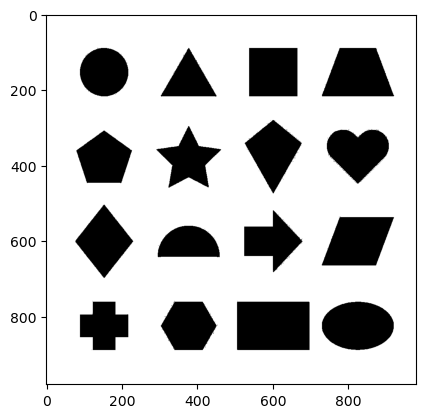

In [207]:
# Method (2) : to use Thresholding technique instead of Canny
# ----------------------------------------------------------------
# Load the image and get it as greyscale
image2 = cv2.imread("./images/shapes.jpg")

# Check if the image is loaded
if image2 is None:
    print(" Error: Can't load the image")
else:
    print("Image Loaded Successfully.")

# Convert to grayscale
img_grey2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# cv2.threshold( ) Converts the grayscale image into a binary image.
# Pixels with intensity greater than 200 are set to 255 (white).
# Pixels with intensity less than or equal to 200 are set to 0 (black).
# retval holds the threshold value used (which is 200 here, but it can be useful if you're using certain adaptive thresholding methods).
# So, it Modify image colors, by converting all color values greater than 200 to be white
# Any pixel color > 200 will be 1 (white), and colors < 200 will be 0 (black)
# THRESH_BINARY to binary convert the 200 < values, values > 200  to 0,1s.
retval, binary = cv2.threshold(img_grey2, 240, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='grey')

# Pass the grey image to contour detection, take two inputs
# Mode: determines Hirarchical relathionship between contours
# Method: define the way on how the contours points are stored
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on the mask with black color (0)
cv2.drawContours(mask, contours, -1, 0, thickness=cv2.FILLED)




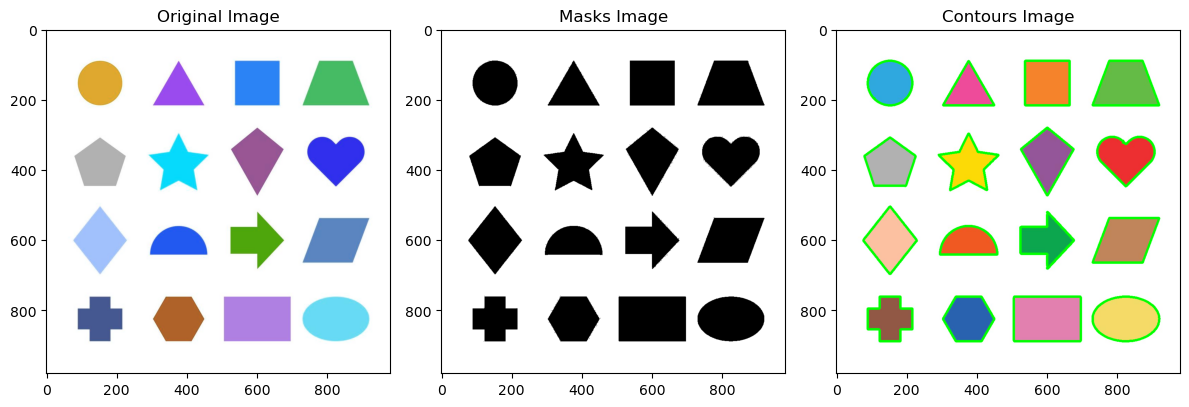

In [208]:
# Plots
# Show all resized images with each algorithm
plt.figure(figsize=(12,9))

# Show the original Image
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

# Show the masks image
plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Masks Image")

# Show the  edges (Contours)
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contours Image")

plt.tight_layout()
plt.show()

Image Loaded Successfully.


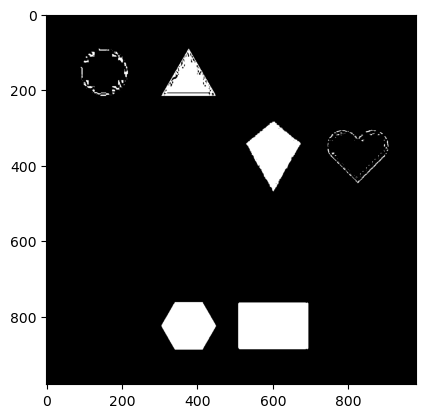

In [225]:
# Method (3) : Lower, upper bound in Range to detect certain colors
# ----------------------------------------------------------------

# Load the image and get it as greyscale
image2 = cv2.imread("./images/shapes.jpg")

# Check if the image is loaded
if image2 is None:
    print(" Error: Can't load the image")
else:
    print("Image Loaded Successfully.")


# Define Lower and Upper bounds for the image colors
lower_bound = np.array([100, 100, 30], dtype=np.uint8)
upper_bound = np.array([240, 240, 240], dtype=np.uint8)

# Create two different images one rgb, other hsv
image_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image_hsv = cv2.cvtColor(image2, cv2.COLOR_BGR2HSV)

# Now, I want to target certain colors from my image, so I use HSV, to get a mask for only certain shape colors
mask = cv2.inRange(image_hsv,lower_bound, upper_bound)

plt.imshow(mask, cmap='grey')
contours, hierarchy = cv2.findContours(mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)




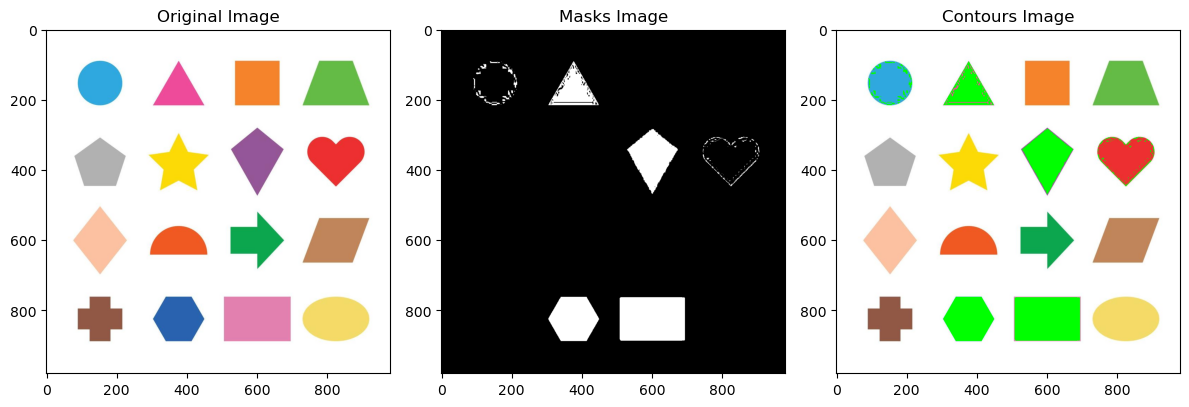

In [226]:
# Plots
contour_image= image.copy()
cv2.drawContours(contour_image, contours, -1, (0,255,0), -1)

# Show all resized images with each algorithm
plt.figure(figsize=(12,9))

# Show the original Image
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

# Show the masks image
plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Masks Image")

# Show the  edges (Contours)
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contours Image")

plt.tight_layout()
plt.show()

Image Loaded Successfully.


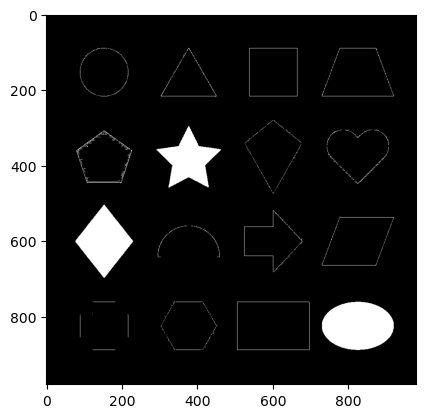

In [230]:
# Method (4) : Using grey scale image 
# ----------------------------------------------------------------

# Load the image and get it as greyscale
image3 = cv2.imread("./images/shapes.jpg")

# Check if the image is loaded
if image2 is None:
    print(" Error: Can't load the image")
else:
    print("Image Loaded Successfully.")


# Define Lower and Upper bounds for the image colors
lower_bound = np.array([180], dtype=np.uint8)
upper_bound = np.array([240], dtype=np.uint8)

# Create two different images one rgb, other hsv
image_rgb = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)
image_hsv = cv2.cvtColor(image3, cv2.COLOR_BGR2HSV)
image_grey = cv2.cvtColor(image3, cv2.COLOR_BGR2GRAY)

mask = cv2.inRange(image_grey,lower_bound, upper_bound)

plt.imshow(mask, cmap='grey')
contours, hierarchy = cv2.findContours(mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)


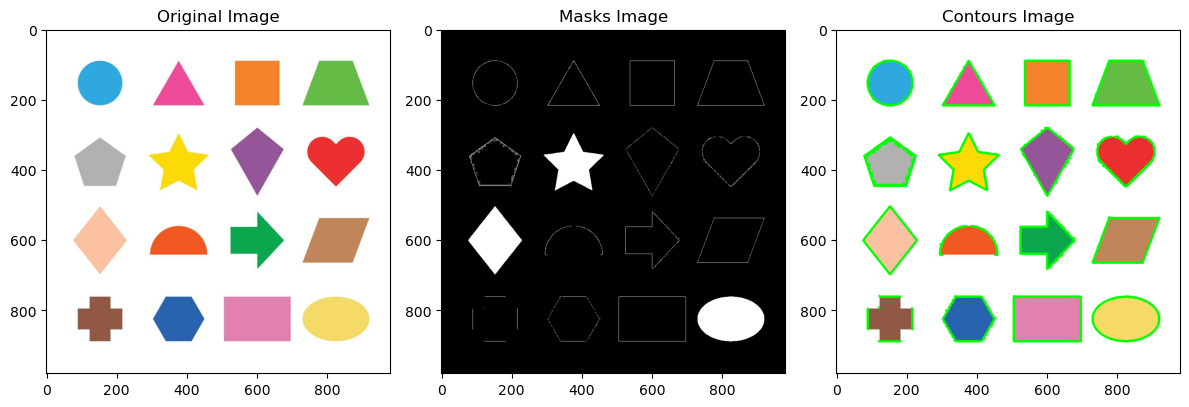

In [231]:

contour_image= image.copy()
cv2.drawContours(contour_image, contours, -1, (0,255,0), 5)

# Show all resized images with each algorithm
plt.figure(figsize=(12,9))

# Show the original Image
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image3, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

# Show the masks image
plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Masks Image")

# Show the  edges (Contours)
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("Contours Image")

plt.tight_layout()
plt.show()